Generating Base Signals...


Calculating Base Indicators: 100%|██████████| 402/402 [00:30<00:00, 13.30it/s]


Running Daily Walk-Forward Tournament...


Ranking & Allocating: 100%|██████████| 397/397 [00:05<00:00, 78.58it/s]



--- Final Strategy Performance ($10,000 Portfolio) ---


,Strategy,Final Equity ($),Total Profit ($),Sharpe,Accuracy (%)
0,Dynamic Regression (Top 5),"$9,246.47",$-753.53,-0.28,47.61%
1,Dynamic Hurst (Top 5),"$11,473.82","$1,473.82",1.22,53.91%
2,SPY Intraday Benchmark,"$10,458.90",$458.90,0.23,52.69%



--- Side Output: Daily Top 5 Asset Allocations (Tail) ---


,Date,Strategy,Stock,Cumulated Result (%),Accuracy (%),Action Today
1970,2026-02-18,Hurst,DLTR,44.82,62.37,Short
1971,2026-02-18,Hurst,IT,25.04,54.12,Short
1972,2026-02-18,Hurst,LULU,22.99,53.27,Short
1973,2026-02-18,Hurst,SW,9.43,38.89,Short
1974,2026-02-18,Hurst,TRMB,8.98,50.00,Short
1975,2026-02-19,Hurst,DLTR,44.82,62.37,Short
1976,2026-02-19,Hurst,IT,25.04,54.12,Short
1977,2026-02-19,Hurst,LULU,20.10,52.78,Short
1978,2026-02-19,Hurst,SW,9.43,38.89,Short
1979,2026-02-19,Hurst,TRMB,8.98,50.00,Short


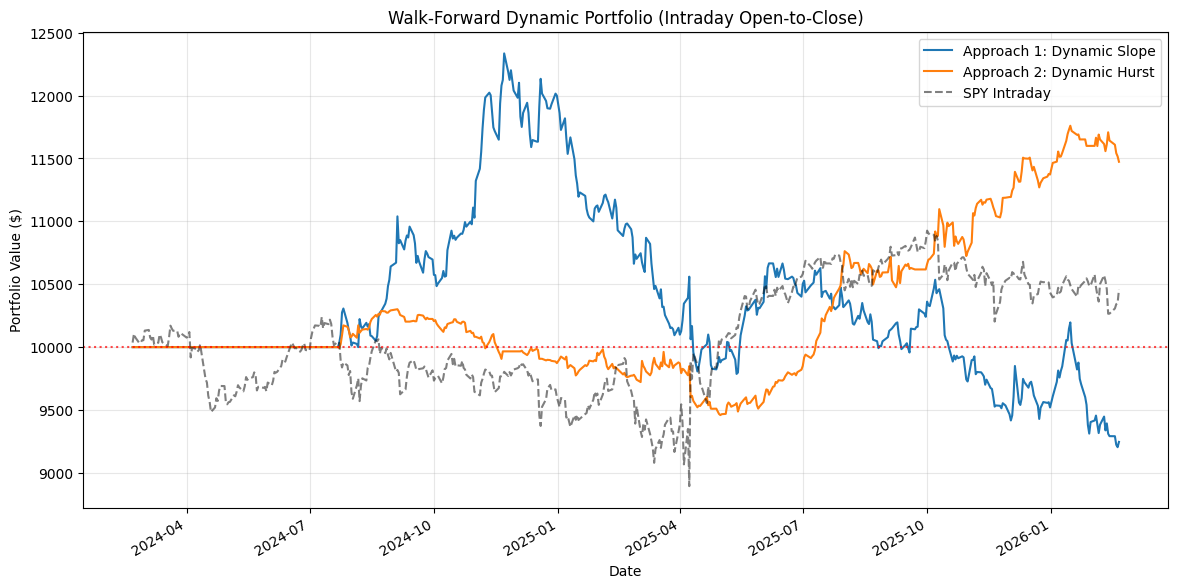

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# --- 1. DATA SETUP ---
tickers = ["PPG", "DG", "TPL", "RF", "CHD", "EIX", "LH", "DRI", "CDW", "WAT",
           "L", "DVN", "TYL", "SBAC", "ON", "IP", "WST", "LULU", "DLTR", "NI",
           "ZBH", "NVR", "KEY", "DGX", "RL", "SW", "TRMB", "BG", "GPN", "IT",
           "J", "PFG", "CPAY", "INCY", "TSN", "AMCR", "CHRW", "CTRA", "GDDY", "SPY"]

print("Downloading Data...")
raw_data = yf.download(tickers, period="2y", interval="1d", auto_adjust=True, progress=False)
prices = raw_data['Close'].dropna(axis=1)
opens = raw_data['Open'][prices.columns]
ret_intra = (prices - opens) / opens

asset_list = [c for c in prices.columns if c != 'SPY']

# --- 2. BASE SIGNAL GENERATION (Vectorized & Fast) ---
print("Generating Base Signals...")
sig_slope = pd.DataFrame(0, index=prices.index, columns=asset_list)
sig_hurst = pd.DataFrame(0, index=prices.index, columns=asset_list)

def get_hurst(series):
    lags = range(2, 20)
    tau = [np.sqrt(np.std(np.subtract(series[lag:], series[:-lag]))) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] * 2.0

# Pre-calculate indicators for speed
ema9 = prices[asset_list].ewm(span=9).mean()
ema21 = prices[asset_list].ewm(span=21).mean()

for t in tqdm(range(100, len(prices)), desc="Calculating Base Indicators"):
    date = prices.index[t]

    for col in asset_list:
        # Approach 1: 30-Day Regression Slope (+1 Long, -1 Short)
        y = prices[col].iloc[t-30:t].values
        x = np.arange(len(y))
        slope, _, _, _, _ = linregress(x, y)
        sig_slope.at[date, col] = 1 if slope > 0 else -1

        # Approach 2: Hurst Regime + EMA Cross (+1 Long, -1 Short)
        window_hurst = prices[col].iloc[t-100:t].values
        h_val = get_hurst(window_hurst)

        if h_val > 0.52: # If trending regime
            if ema9[col].iloc[t] > ema21[col].iloc[t]:
                sig_hurst.at[date, col] = 1
            else:
                sig_hurst.at[date, col] = -1

# --- 3. DYNAMIC PORTFOLIO SELECTION (Walk-Forward) ---
print("Running Daily Walk-Forward Tournament...")

# Calculate "Paper Trading" hypothetical returns for the base signals
# Shift by 1 because yesterday's signal trades today's return
hypo_ret_slope = sig_slope.shift(1) * ret_intra[asset_list]
hypo_ret_hurst = sig_hurst.shift(1) * ret_intra[asset_list]

final_alloc_slope = pd.DataFrame(0.0, index=prices.index, columns=asset_list)
final_alloc_hurst = pd.DataFrame(0.0, index=prices.index, columns=asset_list)

side_output_data = []

# Start tournament on day 105 (giving the hypothetical tracker 5 days to build data)
for t in tqdm(range(105, len(prices)), desc="Ranking & Allocating"):
    date = prices.index[t]

    # --- Strategy 1: Slope Tournament ---
    # Performance up to yesterday
    hist_perf_slope = hypo_ret_slope.iloc[100:t]
    cum_perf_slope = hist_perf_slope.sum()

    # Select Top 5 assets with best historical strategy performance
    top_5_slope = cum_perf_slope.nlargest(5).index

    # Allocate 20% capital to each of the Top 5 based on today's signal
    for stock in top_5_slope:
        final_alloc_slope.at[date, stock] = sig_slope.at[date, stock] * 0.20

    # --- Strategy 2: Hurst Tournament & Side Output ---
    hist_perf_hurst = hypo_ret_hurst.iloc[100:t]
    cum_perf_hurst = hist_perf_hurst.sum()

    # Calculate historical accuracy for tracking
    wins = (hist_perf_hurst > 0).sum()
    total_trades = (hist_perf_hurst != 0).sum()
    accuracy_hurst = wins / total_trades.replace(0, 1) # Avoid division by zero

    top_5_hurst = cum_perf_hurst.nlargest(5).index

    for stock in top_5_hurst:
        final_alloc_hurst.at[date, stock] = sig_hurst.at[date, stock] * 0.20

        # Log side output specifically for Hurst Strategy
        side_output_data.append({
            "Date": date.date(),
            "Strategy": "Hurst",
            "Stock": stock,
            "Cumulated Result (%)": round(cum_perf_hurst[stock] * 100, 2),
            "Accuracy (%)": round(accuracy_hurst[stock] * 100, 2),
            "Action Today": "Long" if sig_hurst.at[date, stock] == 1 else "Short"
        })

# --- 4. PERFORMANCE ANALYTICS ---
# Calculate actual portfolio returns
port_ret_slope = (final_alloc_slope * ret_intra[asset_list]).sum(axis=1)
port_ret_hurst = (final_alloc_hurst * ret_intra[asset_list]).sum(axis=1)

def calc_metrics_usd(returns, name, initial_capital=10000):
    equity_curve = initial_capital * (1 + returns).cumprod()
    daily_pnl = equity_curve.diff().fillna(0)

    active_rets = returns[returns != 0]
    total_profit = equity_curve.iloc[-1] - initial_capital
    sharpe = (active_rets.mean() / active_rets.std()) * np.sqrt(252) if len(active_rets) > 1 else 0
    acc = (active_rets > 0).sum() / len(active_rets) if not active_rets.empty else 0

    return {
        "Strategy": name,
        "Final Equity ($)": f"${equity_curve.iloc[-1]:,.2f}",
        "Total Profit ($)": f"${total_profit:,.2f}",
        "Sharpe": round(sharpe, 2),
        "Accuracy (%)": f"{acc * 100:.2f}%"
    }, equity_curve

m_slope, eq_slope = calc_metrics_usd(port_ret_slope, "Dynamic Regression (Top 5)")
m_hurst, eq_hurst = calc_metrics_usd(port_ret_hurst, "Dynamic Hurst (Top 5)")
m_spy, eq_spy = calc_metrics_usd(ret_intra['SPY'], "SPY Intraday Benchmark")

print("\n\n--- Final Strategy Performance ($10,000 Portfolio) ---")
display(pd.DataFrame([m_slope, m_hurst, m_spy]))

# Display the Side Output
df_side_output = pd.DataFrame(side_output_data)
print("\n--- Side Output: Daily Top 5 Asset Allocations (Tail) ---")
display(df_side_output.tail(15)) # Showing the last 3 days of allocations (3 days * 5 stocks)

# Plotting
plt.figure(figsize=(14,7))
eq_slope.plot(label="Approach 1: Dynamic Slope")
eq_hurst.plot(label="Approach 2: Dynamic Hurst")
eq_spy.plot(label="SPY Intraday", alpha=0.5, color='black', linestyle='--')
plt.axhline(10000, color='red', linestyle=':', alpha=0.7)
plt.title("Walk-Forward Dynamic Portfolio (Intraday Open-to-Close)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Using specific set of PARAMETERS**


arima_scenarios = {
    "ARIMA_Fast": {"lookback": 20, "order": (1,1,0)},
    "ARIMA_Base": {"lookback": 30, "order": (2,1,1)},
    "ARIMA_Slow": {"lookback": 50, "order": (5,1,0)}
}

hurst_scenarios = {
    "Hurst_Loose": {"lags": range(2, 15), "thresh": 0.52},
    "Hurst_Base":  {"lags": range(2, 20), "thresh": 0.58},
    "Hurst_Strict": {"lags": range(5, 30), "thresh": 0.62}
}


In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ==========================================
# 1. SETUP & DATA ACQUISITION
# ==========================================
tickers = ["PPG", "DG", "TPL", "RF", "CHD", "EIX", "LH", "DRI", "CDW", "WAT",
           "L", "DVN", "TYL", "SBAC", "ON", "IP", "WST", "LULU", "DLTR", "NI",
           "ZBH", "NVR", "KEY", "DGX", "RL", "SW", "TRMB", "BG", "GPN", "IT",
           "J", "PFG", "CPAY", "INCY", "TSN", "AMCR", "CHRW", "CTRA", "GDDY", "SPY"]

print("Downloading Data...")
raw_data = yf.download(tickers, period="2y", interval="1d", auto_adjust=True, progress=False)
prices = raw_data['Close'].dropna(axis=1)
opens = raw_data['Open'][prices.columns]

# Intraday returns (Open to Close)
ret_intra = (prices - opens) / opens
asset_list = [c for c in prices.columns if c != 'SPY']

# ==========================================
# 2. SCENARIO PARAMETERS (Grid Search)
# ==========================================
arima_scenarios = {
    "ARIMA_Original": {"lookback": 30, "order": (1,1,0)}, # <--- Your Original Setup
    "ARIMA_Fast": {"lookback": 20, "order": (1,1,0)},
    "ARIMA_Base": {"lookback": 30, "order": (2,1,1)},
    "ARIMA_Slow": {"lookback": 50, "order": (5,1,0)}
}

hurst_scenarios = {
    "Hurst_Original": {"lags": range(2, 20), "thresh": 0.52}, # <--- Adds Code 1 logic
    "Hurst_Loose": {"lags": range(2, 15), "thresh": 0.52},
    "Hurst_Base":  {"lags": range(2, 20), "thresh": 0.58},
    "Hurst_Strict": {"lags": range(5, 30), "thresh": 0.62}
}

# Store signals for all 6 strategies
signals = {name: pd.DataFrame(0, index=prices.index, columns=asset_list) for name in list(arima_scenarios.keys()) + list(hurst_scenarios.keys())}

def get_hurst_dynamic(series, lags):
    tau = [np.sqrt(np.std(np.subtract(series[lag:], series[:-lag]))) for lag in lags]
    poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
    return poly[0] * 2.0

# Pre-calculate EMA for Hurst directional bias (+1 Long, -1 Short)
ema9 = prices[asset_list].ewm(span=9).mean()
ema21 = prices[asset_list].ewm(span=21).mean()

# ==========================================
# 3. BASE SIGNAL GENERATION (The Heavy Loop)
# ==========================================
start_idx = 100 # Need at least 100 days for the longest lookbacks/tournaments
print("Generating Base Signals (Grab a coffee, this will take time)...")

for t in tqdm(range(start_idx, len(prices)-1), desc="Daily Iterations"):
    today = prices.index[t]
    tomorrow = prices.index[t+1]

    for col in asset_list:
        current_price = prices[col].iloc[t]

        # --- ARIMA Scenarios ---
        for name, params in arima_scenarios.items():
            try:
                window = prices[col].iloc[t-params["lookback"]:t+1].values
                model = ARIMA(window, order=params["order"]).fit(method='yule_walker')
                forecast = model.forecast(steps=1)[0]
                # Directional Bias
                signals[name].at[tomorrow, col] = 1 if forecast > current_price else -1
            except:
                pass # If ARIMA fails to converge, stay flat (0)

        # --- Hurst Scenarios ---
        for name, params in hurst_scenarios.items():
            window = prices[col].iloc[t-100:t+1].values
            h_val = get_hurst_dynamic(window, params["lags"])

            # If trending regime confirmed, use EMA cross for direction
            if h_val > params["thresh"]:
                if ema9[col].iloc[t] > ema21[col].iloc[t]:
                    signals[name].at[tomorrow, col] = 1   # Long
                else:
                    signals[name].at[tomorrow, col] = -1  # Short

# ==========================================
# 4. WALK-FORWARD PORTFOLIO ALLOCATION
# ==========================================
print("Running Daily Walk-Forward Tournament...")

final_allocations = {name: pd.DataFrame(0.0, index=prices.index, columns=asset_list) for name in signals.keys()}
side_output_data = []

# We start tournament on day 105 to give the tracker 5 days of hypothetical history
for t in tqdm(range(105, len(prices)), desc="Ranking Top 5"):
    date = prices.index[t]

    for strategy_name, sig_df in signals.items():
        # Hypothetical returns of this strategy up to yesterday
        hypo_ret = sig_df.shift(1).iloc[100:t] * ret_intra[asset_list].iloc[100:t]
        cum_perf = hypo_ret.sum()

        # Select Top 5 assets with best historical strategy performance
        top_5 = cum_perf.nlargest(5).index

        for stock in top_5:
            action = sig_df.at[date, stock]
            final_allocations[strategy_name].at[date, stock] = action * 0.20 # 20% capital each

            # Record Side Output for Transparency
            if action != 0:
                wins = (hypo_ret[stock] > 0).sum()
                total_trades = (hypo_ret[stock] != 0).sum()
                acc = wins / total_trades if total_trades > 0 else 0

                side_output_data.append({
                    "Date": date.date(),
                    "Strategy": strategy_name,
                    "Stock": stock,
                    "Cumulated Result (%)": round(cum_perf[stock] * 100, 2),
                    "Accuracy (%)": round(acc * 100, 2),
                    "Action Today": "Long" if action == 1 else "Short"
                })

# ==========================================
# 5. PERFORMANCE ANALYTICS & PLOTTING
# ==========================================
def calc_metrics_usd(returns, name, initial_capital=10000):
    equity_curve = initial_capital * (1 + returns).cumprod()
    active_rets = returns[returns != 0]
    total_profit = equity_curve.iloc[-1] - initial_capital
    sharpe = (active_rets.mean() / active_rets.std()) * np.sqrt(252) if len(active_rets) > 1 else 0
    acc = (active_rets > 0).sum() / len(active_rets) if not active_rets.empty else 0

    return {
        "Strategy": name,
        "Final Equity ($)": f"${equity_curve.iloc[-1]:,.2f}",
        "Total Profit ($)": f"${total_profit:,.2f}",
        "Sharpe": round(sharpe, 2),
        "Accuracy (%)": f"{acc * 100:.2f}%"
    }, equity_curve

results_list = []
equity_curves = {}

# Calculate metrics for all 6 scenarios
for name, alloc_df in final_allocations.items():
    port_ret = (alloc_df * ret_intra[asset_list]).sum(axis=1)
    metrics, eq_curve = calc_metrics_usd(port_ret, name)
    results_list.append(metrics)
    equity_curves[name] = eq_curve

# Add SPY Benchmark
spy_metrics, spy_eq = calc_metrics_usd(ret_intra['SPY'], "SPY Intraday")
results_list.append(spy_metrics)
equity_curves["SPY Intraday"] = spy_eq

print("\n\n--- Strategy Performance Grid ($10,000 Initial Capital) ---")
display(pd.DataFrame(results_list))

print("\n--- Side Output: Daily Top 5 Asset Allocations (Tail) ---")
df_side_output = pd.DataFrame(side_output_data)
display(df_side_output.tail(15))



Generating Base Signals (Grab a coffee, this will take time)...


Daily Iterations: 100%|██████████| 401/401 [08:42<00:00,  1.30s/it]


Running Daily Walk-Forward Tournament...


Ranking Top 5: 100%|██████████| 397/397 [00:21<00:00, 18.77it/s]




--- Strategy Performance Grid ($10,000 Initial Capital) ---


,Strategy,Final Equity ($),Total Profit ($),Sharpe,Accuracy (%)
0,ARIMA_Fast,"$11,182.11","$1,182.11",0.55,52.90%
1,ARIMA_Base,"$10,000.00",$0.00,0.00,0.00%
2,ARIMA_Slow,"$11,601.51","$1,601.51",0.75,50.63%
3,Hurst_Loose,"$9,163.17",$-836.83,-0.81,51.57%
4,Hurst_Base,"$10,084.40",$84.40,0.20,56.93%
5,Hurst_Strict,"$10,483.74",$483.74,1.22,55.07%
6,SPY Intraday,"$10,458.90",$458.90,0.23,52.69%



--- Side Output: Daily Top 5 Asset Allocations (Tail) ---


,Date,Strategy,Stock,Cumulated Result (%),Accuracy (%),Action Today
5042,2026-02-19,ARIMA_Slow,GPN,42.11,49.25,Long
5043,2026-02-19,ARIMA_Slow,ZBH,39.22,51.89,Long
5044,2026-02-19,Hurst_Loose,BG,16.80,58.06,Long
5045,2026-02-19,Hurst_Loose,LULU,6.96,50.00,Short
5046,2026-02-20,ARIMA_Fast,CDW,77.18,55.89,Short
5047,2026-02-20,ARIMA_Fast,AMCR,67.40,58.29,Long
5048,2026-02-20,ARIMA_Fast,TPL,60.58,50.38,Long
5049,2026-02-20,ARIMA_Fast,GDDY,48.08,52.39,Long
5050,2026-02-20,ARIMA_Fast,NVR,44.58,52.63,Long
5051,2026-02-20,ARIMA_Slow,WST,106.20,53.02,Long


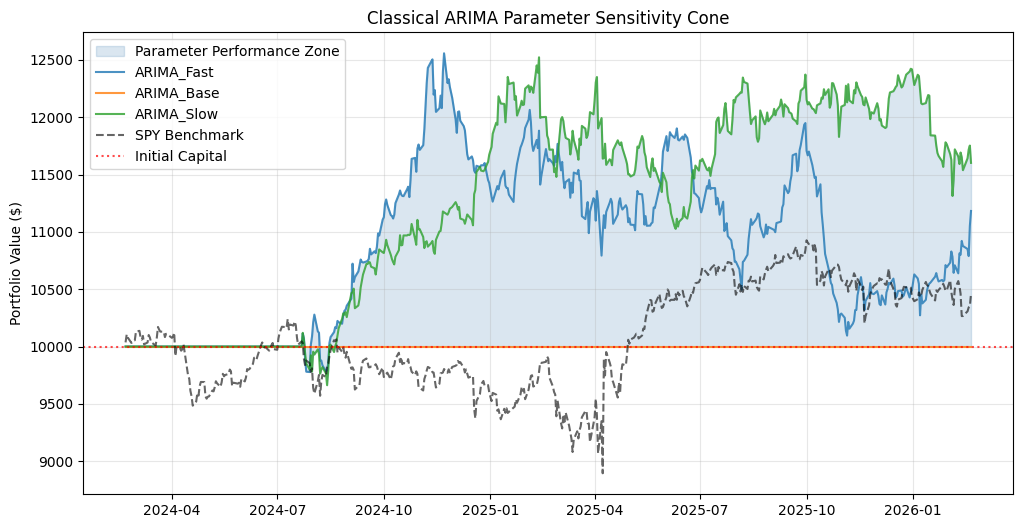

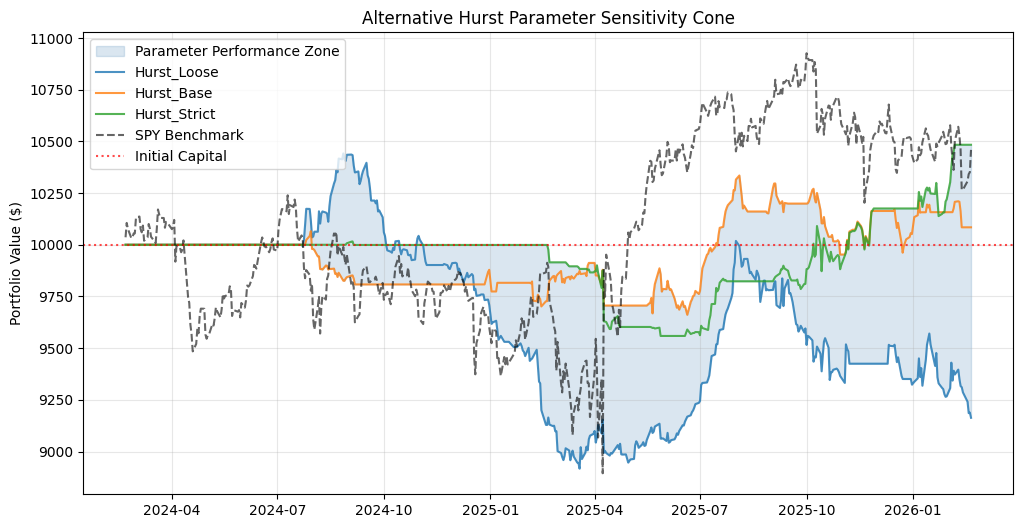

In [15]:
# --- PLOT 1: THE "DARK ZONE" SCENARIO CONES ---

def plot_shaded_scenarios(scenario_keys, title_prefix):
    # Extract only the curves for this specific model (ARIMA or Hurst)
    subset_curves = {k: equity_curves[k] for k in scenario_keys}
    df_curves = pd.DataFrame(subset_curves)

    # Calculate the boundaries
    max_curve = df_curves.max(axis=1)
    min_curve = df_curves.min(axis=1)

    plt.figure(figsize=(12, 6))

    # Fill the "Dark Zone"
    plt.fill_between(df_curves.index, min_curve, max_curve, color='steelblue', alpha=0.2, label='Parameter Performance Zone')

    # Plot the individual scenarios inside the zone
    for name in df_curves.columns:
        plt.plot(df_curves.index, df_curves[name], alpha=0.8, linewidth=1.5, label=name)

    # Add Benchmark and Baseline
    plt.plot(equity_curves["SPY Intraday"].index, equity_curves["SPY Intraday"], color='black', linestyle='--', alpha=0.6, label='SPY Benchmark')
    plt.axhline(10000, color='red', linestyle=':', alpha=0.7, label='Initial Capital')

    plt.title(f"{title_prefix} Parameter Sensitivity Cone")
    plt.ylabel("Portfolio Value ($)")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

# Execute for ARIMA
plot_shaded_scenarios(arima_scenarios.keys(), "Classical ARIMA")

# Execute for Hurst
plot_shaded_scenarios(hurst_scenarios.keys(), "Alternative Hurst")

🏆 Winning Strategy Selected for Monte Carlo: ARIMA_Slow
Running Monte Carlo Simulation (1000 paths)...


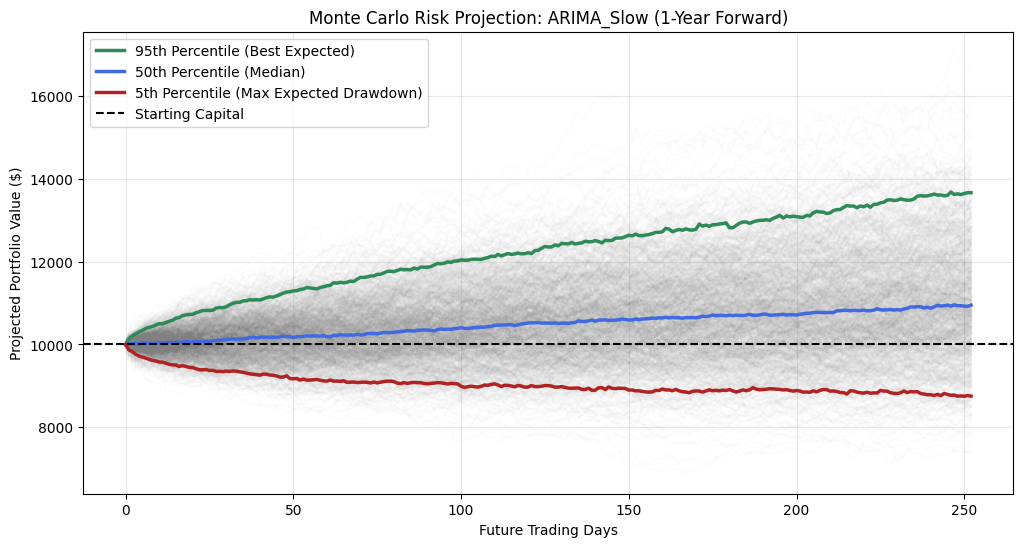


--- Monte Carlo Forward Risk Analytics (252 Days) ---
Median Expected Ending Equity: $10,949.07
Absolute Risk Limit (5th Pct): $8,752.46 <- System shutdown threshold
Probability of Profitability:  77.00%


In [16]:
# --- PLOT 2: MONTE CARLO SIMULATION ON THE WINNER ---

# 1. Automatically find the best strategy by Final Equity (excluding SPY)
best_strategy = None
highest_equity = 0

for res in results_list:
    if res['Strategy'] != "SPY Intraday":
        # Clean the string "$10,500.00" to float 10500.00
        eq_val = float(res['Final Equity ($)'].replace('$', '').replace(',', ''))
        if eq_val > highest_equity:
            highest_equity = eq_val
            best_strategy = res['Strategy']

print(f"🏆 Winning Strategy Selected for Monte Carlo: {best_strategy}")

# 2. Extract the daily returns of the winner
# Re-calculate the daily percentage return stream for the best strategy
best_alloc_df = final_allocations[best_strategy]
winning_daily_returns = (best_alloc_df * ret_intra[asset_list]).sum(axis=1)

# 3. Monte Carlo Engine
def run_monte_carlo(daily_returns, initial_capital=10000, num_simulations=1000, trading_days=252):
    print(f"Running Monte Carlo Simulation ({num_simulations} paths)...")

    # Only bootstrap the days we actively traded
    active_returns = daily_returns[daily_returns != 0].dropna().values

    simulation_df = np.zeros((trading_days + 1, num_simulations))
    simulation_df[0, :] = initial_capital

    for x in range(num_simulations):
        # Randomly sample returns with replacement
        simulated_rets = np.random.choice(active_returns, size=trading_days, replace=True)
        simulation_df[1:, x] = initial_capital * (1 + simulated_rets).cumprod()

    sim_df = pd.DataFrame(simulation_df)

    # Confidence Intervals
    p5 = sim_df.quantile(0.05, axis=1)  # Worst Case
    p50 = sim_df.quantile(0.50, axis=1) # Median Case
    p95 = sim_df.quantile(0.95, axis=1) # Best Case

    return sim_df, p5, p50, p95

sim_data, p5, p50, p95 = run_monte_carlo(winning_daily_returns)

# 4. Plotting the Monte Carlo Fan Chart
plt.figure(figsize=(12, 6))

# Plot all background paths very lightly
plt.plot(sim_data, color='gray', alpha=0.02)

# Plot the Statistical Boundaries
plt.plot(p95, color='seagreen', linewidth=2.5, label='95th Percentile (Best Expected)')
plt.plot(p50, color='royalblue', linewidth=2.5, label='50th Percentile (Median)')
plt.plot(p5, color='firebrick', linewidth=2.5, label='5th Percentile (Max Expected Drawdown)')

plt.axhline(10000, color='black', linestyle='--', label='Starting Capital')
plt.title(f"Monte Carlo Risk Projection: {best_strategy} (1-Year Forward)")
plt.xlabel("Future Trading Days")
plt.ylabel("Projected Portfolio Value ($)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Monte Carlo Forward Risk Analytics (252 Days) ---")
print(f"Median Expected Ending Equity: ${p50.iloc[-1]:,.2f}")
print(f"Absolute Risk Limit (5th Pct): ${p5.iloc[-1]:,.2f} <- System shutdown threshold")
print(f"Probability of Profitability:  {(sim_data.iloc[-1] > 10000).mean() * 100:.2f}%")